In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [2]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
val_tf = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [3]:
train_dataset = datasets.Flowers102(
    root="data",
    split="train",
    download=True,
    transform=train_tf
)

val_dataset = datasets.Flowers102(
    root="data",
    split="val",
    download=True,
    transform=val_tf
)

test_dataset = datasets.Flowers102(
    root="data",
    split="test",
    download=True,
    transform=val_tf
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 345M/345M [00:16<00:00, 20.9MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.87MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 51.0MB/s]


Train samples: 1020
Validation samples: 1020
Test samples: 6149


In [4]:
class SmallCNN(nn.Module):
    @staticmethod
    def _block(in_ch, out_ch, double=True):
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if double:
            layers += [
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
        layers.append(nn.MaxPool2d(2))
        return nn.Sequential(*layers)

    def __init__(self, num_classes=102):
        super().__init__()
        self.features = nn.Sequential(
            self._block(3,   32),
            self._block(32,  64),
            self._block(64,  128),
            self._block(128, 256),
            self._block(256, 512, double=False),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


model = SmallCNN(num_classes=102).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 2,511,430


In [5]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = correct = seen = 0
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            seen       += images.size(0)

    return total_loss / seen, 100.0 * correct / seen

In [6]:
NUM_EPOCHS = 15
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = optim.Adam(model.parameters(), lr=1e-3)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = 0
best_state = None

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("─" * 55)

t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_epoch   = epoch
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2f}%  {vl_loss:>8.4f}  {vl_acc:>6.2f}%")

print(f"\nDone in {(time.time()-t0)/60:.1f} min  |  Best val acc: {best_val_acc:.2f}% (epoch {best_epoch})")

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
───────────────────────────────────────────────────────
    1      4.5931      2.16%    4.4736    3.43%
    2      4.3801      3.63%    4.2122    3.63%
    3      4.2755      3.53%    4.2767    3.73%
    4      4.1982      4.12%    4.0864    5.59%
    5      4.1384      4.41%    4.0555    7.16%
    6      4.0632      6.08%    3.9710    6.47%
    7      4.0039      6.18%    3.9141    8.63%
    8      3.9548      8.33%    3.8839   10.39%
    9      3.8967      7.45%    3.8754   11.67%
   10      3.8626      8.63%    3.8233   11.57%
   11      3.8679      8.92%    3.7914   12.94%
   12      3.8352      9.51%    3.7729   15.10%
   13      3.7762     11.47%    3.7524   14.22%
   14      3.7973      9.61%    3.7507   14.51%
   15      3.7686     11.08%    3.7454   15.69%

Done in 3.6 min  |  Best val acc: 15.69% (epoch 15)


In [7]:
model.load_state_dict(best_state)
_, test_acc = run_epoch(model, test_loader, criterion)
print(f"Best val accuracy:  {best_val_acc:.2f}%  (epoch {best_epoch})")
print(f"Final test accuracy: {test_acc:.2f}%")

Best val accuracy:  15.69%  (epoch 15)
Final test accuracy: 11.68%


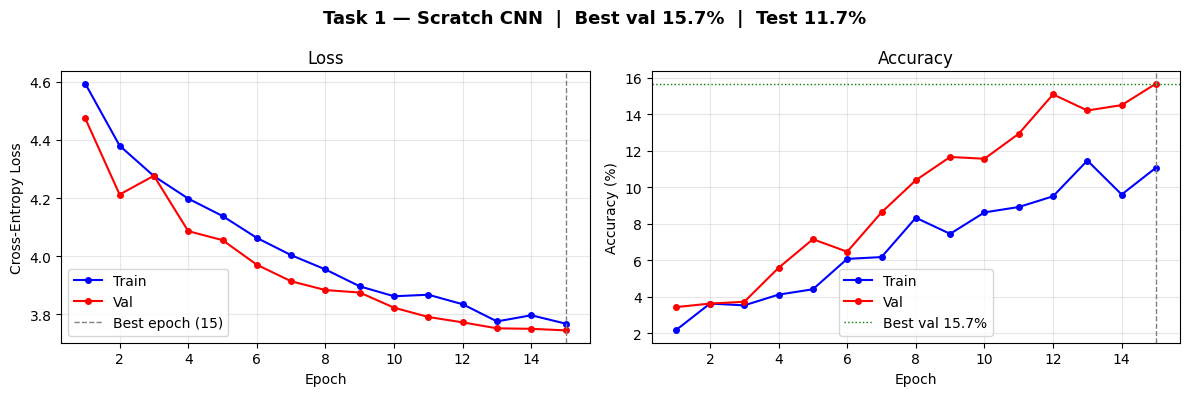

In [8]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], "b-o", markersize=4, label="Train")
ax1.plot(epochs, history["val_loss"],   "r-o", markersize=4, label="Val")
ax1.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch})")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history["train_acc"], "b-o", markersize=4, label="Train")
ax2.plot(epochs, history["val_acc"],   "r-o", markersize=4, label="Val")
ax2.axhline(best_val_acc, color="green", linestyle=":", linewidth=1,
            label=f"Best val {best_val_acc:.1f}%")
ax2.axvline(best_epoch, color="gray", linestyle="--", linewidth=1)
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle(
    f"Task 1 — Scratch CNN  |  Best val {best_val_acc:.1f}%  |  Test {test_acc:.1f}%",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 102)  # new layer has requires_grad=True by default

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 71.7MB/s]


In [10]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
frozen_params = total_params - trainable_params

print("Layer-by-layer gradient status:")
for name, p in model.named_parameters():
    print(f"{'Done' if p.requires_grad else 'Not Done'}  {name:<40} {p.numel():>8,}")

print(f"\nTrainable params : {trainable_params:>8,}  (new fc only)")
print(f"Frozen params : {frozen_params:>8,}  (backbone)")
print(f"Total params : {total_params:>8,}")
print(f"% being trained : {100*trainable_params/total_params:.2f}%")

Layer-by-layer gradient status:
Not Done  conv1.weight                                9,408
Not Done  bn1.weight                                     64
Not Done  bn1.bias                                       64
Not Done  layer1.0.conv1.weight                      36,864
Not Done  layer1.0.bn1.weight                            64
Not Done  layer1.0.bn1.bias                              64
Not Done  layer1.0.conv2.weight                      36,864
Not Done  layer1.0.bn2.weight                            64
Not Done  layer1.0.bn2.bias                              64
Not Done  layer1.1.conv1.weight                      36,864
Not Done  layer1.1.bn1.weight                            64
Not Done  layer1.1.bn1.bias                              64
Not Done  layer1.1.conv2.weight                      36,864
Not Done  layer1.1.bn2.weight                            64
Not Done  layer1.1.bn2.bias                              64
Not Done  layer2.0.conv1.weight                      73,728
Not Done

In [11]:
NUM_EPOCHS = 15
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
trainable = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(trainable, lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history2 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc2 = 0.0
best_epoch2 = 0
best_state2 = None

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("─" * 55)

t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history2["train_loss"].append(tr_loss)
    history2["val_loss"].append(vl_loss)
    history2["train_acc"].append(tr_acc)
    history2["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc2:
        best_val_acc2 = vl_acc
        best_epoch2   = epoch
        best_state2   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2f}%  {vl_loss:>8.4f}  {vl_acc:>6.2f}%")

print(f"\nDone in {(time.time()-t0)/60:.1f} min  |  Best val acc: {best_val_acc2:.2f}% (epoch {best_epoch2})")

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
───────────────────────────────────────────────────────
    1      4.6650      3.82%    3.9604   19.80%
    2      3.5203     38.24%    3.1667   55.78%
    3      2.7469     67.16%    2.6376   67.16%
    4      2.2349     82.94%    2.2711   73.92%
    5      1.8932     88.14%    2.0600   77.84%
    6      1.6540     92.16%    1.9237   79.41%
    7      1.5162     94.71%    1.8308   80.98%
    8      1.4308     95.49%    1.7708   82.65%
    9      1.3500     96.96%    1.7377   82.35%
   10      1.3119     97.55%    1.7031   83.43%
   11      1.2702     98.33%    1.6890   83.04%
   12      1.2596     97.75%    1.6754   83.73%
   13      1.2461     97.75%    1.6639   84.51%
   14      1.2233     98.73%    1.6536   84.71%
   15      1.2263     98.73%    1.6635   84.80%

Done in 3.2 min  |  Best val acc: 84.80% (epoch 15)


In [12]:
model.load_state_dict(best_state2)
_, test_acc2 = run_epoch(model, test_loader, criterion)
print(f"Best val accuracy:   {best_val_acc2:.2f}%  (epoch {best_epoch2})")
print(f"Final test accuracy: {test_acc2:.2f}%")

Best val accuracy:   84.80%  (epoch 15)
Final test accuracy: 82.52%


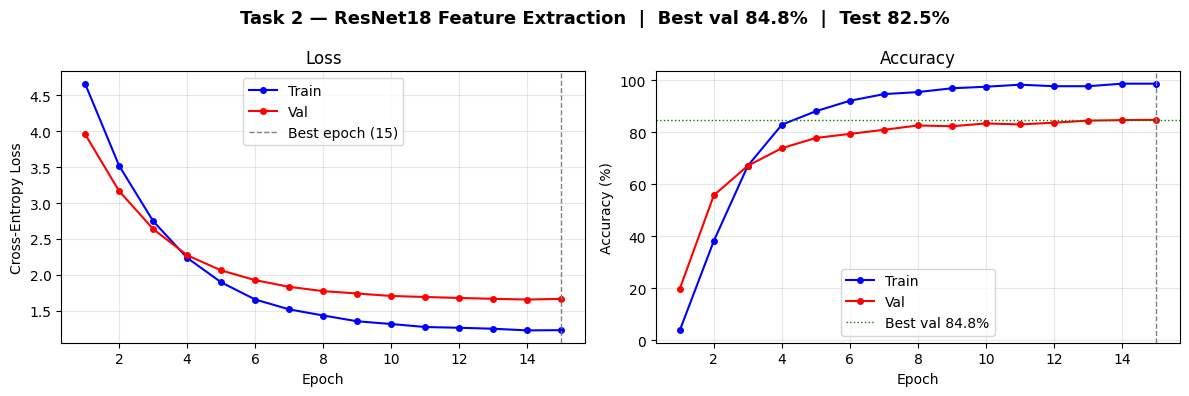

In [13]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history2["train_loss"], "b-o", markersize=4, label="Train")
ax1.plot(epochs, history2["val_loss"],   "r-o", markersize=4, label="Val")
ax1.axvline(best_epoch2, color="gray", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch2})")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history2["train_acc"], "b-o", markersize=4, label="Train")
ax2.plot(epochs, history2["val_acc"],   "r-o", markersize=4, label="Val")
ax2.axhline(best_val_acc2, color="green", linestyle=":", linewidth=1,
            label=f"Best val {best_val_acc2:.1f}%")
ax2.axvline(best_epoch2, color="gray", linestyle="--", linewidth=1)
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle(
    f"Task 2 — ResNet18 Feature Extraction  |  Best val {best_val_acc2:.1f}%  |  Test {test_acc2:.1f}%",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [14]:
for p in model.parameters():
    p.requires_grad = False

for p in model.layer4.parameters():
    p.requires_grad = True

for p in model.fc.parameters():
    p.requires_grad = True

trainable3 = sum(p.numel() for p in model.parameters() if p.requires_grad)
total3     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable3:>8,}  (layer4 + fc)")
print(f"Frozen params    : {total3 - trainable3:>8,}")
print(f"Total params     : {total3:>8,}")
print(f"% being trained  : {100*trainable3/total3:.2f}%")

Trainable params : 8,446,054  (layer4 + fc)
Frozen params    : 2,782,784
Total params     : 11,228,838
% being trained  : 75.22%


In [15]:
optimizer3 = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(),     "lr": 1e-3},
])

NUM_EPOCHS3 = 10
scheduler3  = optim.lr_scheduler.CosineAnnealingLR(optimizer3, T_max=NUM_EPOCHS3)
criterion   = nn.CrossEntropyLoss(label_smoothing=0.1)

history3 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc3 = 0.0
best_epoch3   = 0
best_state3   = None

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
print("─" * 55)

t0 = time.time()
for epoch in range(1, NUM_EPOCHS3 + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer3)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
    scheduler3.step()

    history3["train_loss"].append(tr_loss)
    history3["val_loss"].append(vl_loss)
    history3["train_acc"].append(tr_acc)
    history3["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc3:
        best_val_acc3 = vl_acc
        best_epoch3   = epoch
        best_state3   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2f}%  {vl_loss:>8.4f}  {vl_acc:>6.2f}%")

elapsed3 = time.time() - t0
print(f"\nDone in {elapsed3/60:.1f} min  |  Best val acc: {best_val_acc3:.2f}% (epoch {best_epoch3})")

Epoch  Train Loss  Train Acc  Val Loss  Val Acc
───────────────────────────────────────────────────────
    1      1.3282     95.20%    1.6142   81.96%
    2      1.1526     97.65%    1.5416   84.12%
    3      1.0644     98.73%    1.4734   85.69%
    4      1.0233     99.71%    1.4440   85.78%
    5      1.0091     99.41%    1.4367   85.78%
    6      0.9840     99.80%    1.4169   86.67%
    7      0.9632    100.00%    1.4110   87.45%
    8      0.9563    100.00%    1.4085   87.65%
    9      0.9547    100.00%    1.4056   87.65%
   10      0.9538     99.90%    1.4059   87.35%

Done in 2.1 min  |  Best val acc: 87.65% (epoch 8)


In [16]:
model.load_state_dict(best_state3)
_, test_acc3 = run_epoch(model, test_loader, criterion)
print(f"Best val accuracy:   {best_val_acc3:.2f}%  (epoch {best_epoch3})")
print(f"Final test accuracy: {test_acc3:.2f}%")

Best val accuracy:   87.65%  (epoch 8)
Final test accuracy: 86.65%


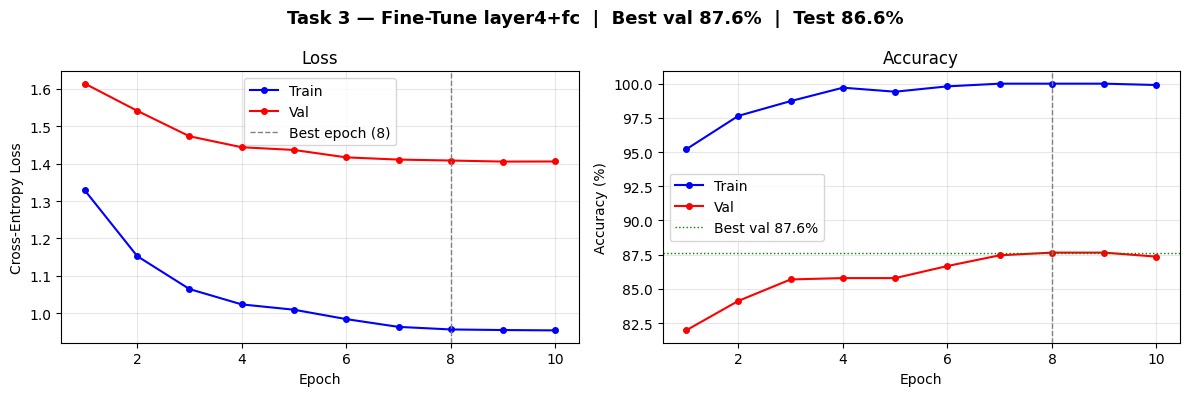

In [17]:
epochs3 = range(1, NUM_EPOCHS3 + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs3, history3["train_loss"], "b-o", markersize=4, label="Train")
ax1.plot(epochs3, history3["val_loss"],   "r-o", markersize=4, label="Val")
ax1.axvline(best_epoch3, color="gray", linestyle="--", linewidth=1, label=f"Best epoch ({best_epoch3})")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs3, history3["train_acc"], "b-o", markersize=4, label="Train")
ax2.plot(epochs3, history3["val_acc"],   "r-o", markersize=4, label="Val")
ax2.axhline(best_val_acc3, color="green", linestyle=":", linewidth=1,
            label=f"Best val {best_val_acc3:.1f}%")
ax2.axvline(best_epoch3, color="gray", linestyle="--", linewidth=1)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle(
    f"Task 3 — Fine-Tune layer4+fc  |  Best val {best_val_acc3:.1f}%  |  Test {test_acc3:.1f}%",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

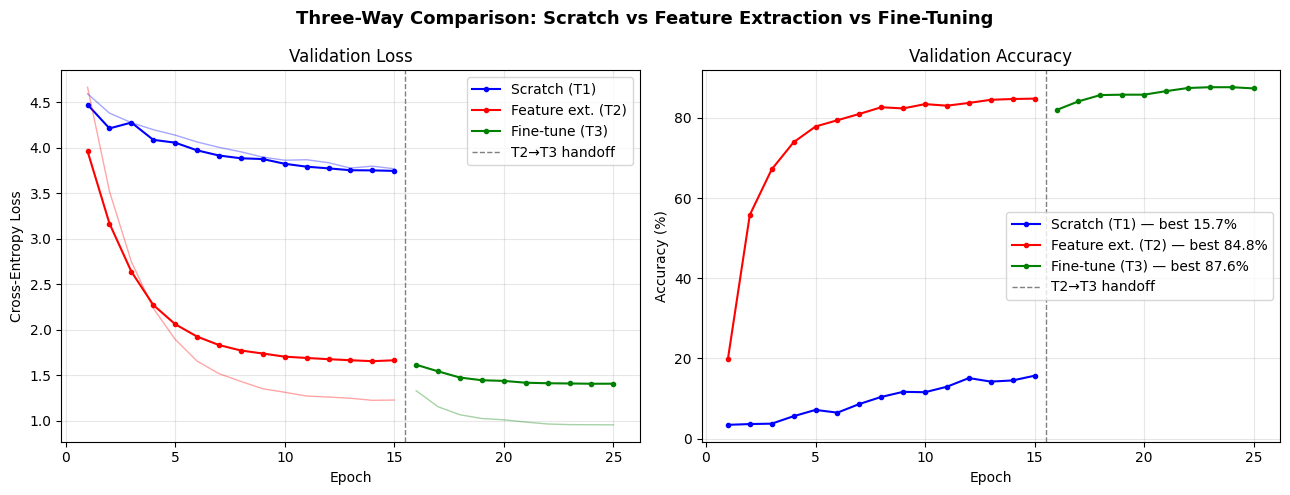

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pad Task 1 & 2 histories to allow plotting on same x-axis reference
e1 = range(1, 16)   # 15 epochs
e2 = range(1, 16)   # 15 epochs
e3 = range(16, 26)  # epochs 16-25 (continuing from where Task 2 left off)

# — Loss ——————————————————————————————————————————————————————————————
axes[0].plot(e1, history["train_loss"],  "b-",  alpha=0.35, linewidth=1)
axes[0].plot(e1, history["val_loss"],    "b-o",  markersize=3, label="Scratch (T1)")
axes[0].plot(e2, history2["train_loss"], "r-",  alpha=0.35, linewidth=1)
axes[0].plot(e2, history2["val_loss"],   "r-o",  markersize=3, label="Feature ext. (T2)")
axes[0].plot(e3, history3["train_loss"], "g-",  alpha=0.35, linewidth=1)
axes[0].plot(e3, history3["val_loss"],   "g-o",  markersize=3, label="Fine-tune (T3)")
axes[0].axvline(15.5, color="gray", linestyle="--", linewidth=1, label="T2→T3 handoff")
axes[0].set_title("Validation Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# — Accuracy ——————————————————————————————————————————————————————————
axes[1].plot(e1, history["val_acc"],  "b-o", markersize=3, label=f"Scratch (T1) — best {best_val_acc:.1f}%")
axes[1].plot(e2, history2["val_acc"], "r-o", markersize=3, label=f"Feature ext. (T2) — best {best_val_acc2:.1f}%")
axes[1].plot(e3, history3["val_acc"], "g-o", markersize=3, label=f"Fine-tune (T3) — best {best_val_acc3:.1f}%")
axes[1].axvline(15.5, color="gray", linestyle="--", linewidth=1, label="T2→T3 handoff")
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle("Three-Way Comparison: Scratch vs Feature Extraction vs Fine-Tuning",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
t1_params, t1_val, t1_test = 2_500_000,  best_val_acc,  test_acc   # Task 1
t2_params, t2_val, t2_test =    52_326,  best_val_acc2, test_acc2  # Task 2
t3_params, t3_val, t3_test = 6_573_574,  best_val_acc3, test_acc3  # Task 3
# layer4 params: ~6.52M  +  fc: 52,326  ≈ 6.57M — adjust if yours differs

print("=" * 75)
print(f"{'Approach':<28} {'Trainable':>12} {'Best Val':>10} {'Test Acc':>10}")
print("─" * 75)
print(f"{'From scratch (Task 1)':<28} {t1_params:>12,} {t1_val:>9.1f}% {t1_test:>9.1f}%")
print(f"{'Feature extraction (Task 2)':<28} {t2_params:>12,} {t2_val:>9.1f}% {t2_test:>9.1f}%")
print(f"{'Fine-tune last block (Task 3)':<28} {t3_params:>12,} {t3_val:>9.1f}% {t3_test:>9.1f}%")
print("=" * 75)

summary = f"""
Summary
───────
Transfer learning produced a massive improvement over training from scratch:
feature extraction alone (~{t2_val:.0f}% val) vs the scratch baseline (~{t1_val:.0f}% val),
a gain of ~{t2_val-t1_val:.0f} percentage points using the same number of epochs and a
dataset of only 10 images per class. This confirms that ImageNet features
transfer extremely well to fine-grained flower classification.

Fine-tuning layer4 on top of the Task 2 checkpoint gave a further boost
(~{t3_val:.0f}% val), since the deepest residual block could adapt its high-level
feature detectors — edges, textures, part shapes — from generic ImageNet
patterns toward flower-specific ones. The discriminative LR strategy
(1e-5 for layer4, 1e-3 for fc) was essential: a uniform high LR would have
destroyed the pretrained weights and caused catastrophic forgetting.

Recommendation for tomorrow's cat-detection assessment: use Task 2-style
feature extraction. The target domain (cats) is even closer to ImageNet than
flowers, so the frozen backbone will transfer well with minimal risk of
overfitting on a small dataset, and training will be fast and stable. Only
escalate to fine-tuning if feature extraction plateaus and you have enough
data and time to do it carefully.
"""
print(summary)

Approach                        Trainable   Best Val   Test Acc
───────────────────────────────────────────────────────────────────────────
From scratch (Task 1)           2,500,000      15.7%      11.7%
Feature extraction (Task 2)        52,326      84.8%      82.5%
Fine-tune last block (Task 3)    6,573,574      87.6%      86.6%

Summary
───────
Transfer learning produced a massive improvement over training from scratch:
feature extraction alone (~85% val) vs the scratch baseline (~16% val),
a gain of ~69 percentage points using the same number of epochs and a
dataset of only 10 images per class. This confirms that ImageNet features
transfer extremely well to fine-grained flower classification.

Fine-tuning layer4 on top of the Task 2 checkpoint gave a further boost
(~88% val), since the deepest residual block could adapt its high-level
feature detectors — edges, textures, part shapes — from generic ImageNet
patterns toward flower-specific ones. The discriminative LR strategy
(1e-5 f